# 淘宝用户行为数据分析 - RFM用户分群

## 1. 加载数据

本Notebook用于基于RFM模型进行用户分群，识别不同价值的用户群体。

In [1]:
import sys
sys.path.append("../src")

from data_loader import load_cleaned_data
from rfm import calculate_rfm,rfm_segmentation,get_segment_stats
from plot_utils import plot_rfm_segment_distribution,plot_rfm_scatter

df = load_cleaned_data()
print(f'本次共加载{len(df)}条数据')

本次共加载9039480条数据


## 2.计算rfm指标

In [2]:
rfm_df = calculate_rfm(df)
print('指标摘要')
display(rfm_df[['R', 'F', 'M']].describe())

指标摘要


,R,F,M
count,10000.000000,10000.000000,10000.000000
mean,1.270900,11.293900,350.763790
std,3.191259,24.349768,550.701129
min,0.000000,0.000000,0.100000
25%,0.000000,2.000000,83.775000
50%,0.000000,7.000000,203.850000
75%,1.000000,14.000000,431.225000
max,30.000000,1720.000000,23568.300000


评分结果

In [3]:
print(rfm_df[['user_id','r_score', 'f_score', 'm_score']].head(10))

   user_id  r_score  f_score  m_score
0     4913        5        2        4
1     6118        5        1        1
2     7528        2        2        2
3     7591        5        4        4
4    12645        5        2        2
5    45368        1        0        1
6    54056        1        1        1
7    63348        3        1        2
8    79824        5        3        3
9    88930        5        4        4


## 3.用户分群

In [4]:
rfm_df = rfm_segmentation(rfm_df)
segment_stats = get_segment_stats(rfm_df)
print(segment_stats)

  segment  count      avg_R      avg_F       avg_M  percentage
0     新用户    575   0.283478   0.000000  108.014609        5.75
1    普通用户    987   2.364742   5.665653  163.498582        9.87
2    核心用户   3075   0.090081  25.738862  763.615415       30.75
3    沉睡用户    364  10.065934   0.000000   28.742857        3.64
4    流失用户    689   7.740203   4.808418  119.683164        6.89
5    潜力用户   2537   0.242018   3.599921  138.638076       25.37
6   高价值用户   1773   0.182741   8.885505  277.151777       17.73


## 4.数据可视化

RFM用户分布直方图

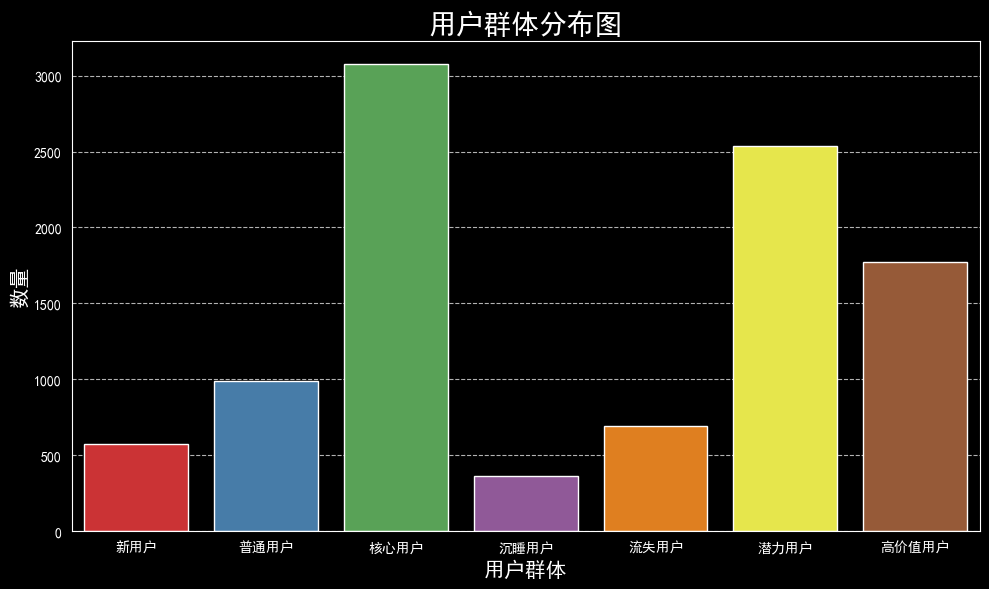

In [5]:
plot_rfm_segment_distribution(segment_stats)

RFM用户分布散点图

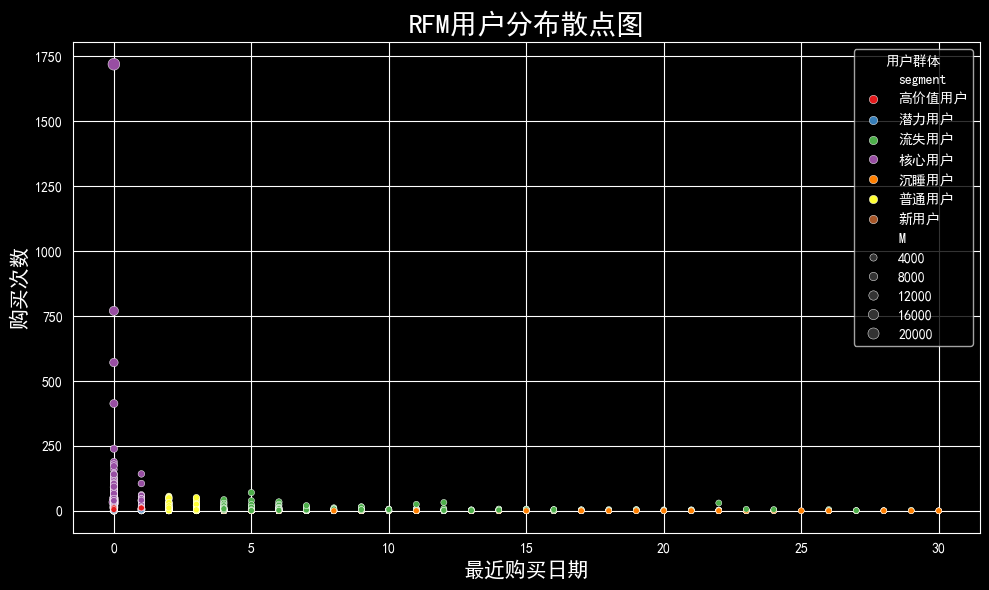

In [6]:
plot_rfm_scatter(rfm_df)